# Robustness metrics on Generative Forests

In [2]:
# Loading required libraries and functions
from functions import *
from gefs import compute_rob_class
from gefs.sklearn_utils import rf2pc
import numpy as np
import pandas as pd
from os import getcwd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [3]:
path="./datasets/"

In [4]:
datasets=['waveform_21','students']

In [5]:
M = 15 # Number of samples used for obtaining mean and std dev
p = 0.3 # Proportion of the data used as the test set
k_cv = 5
fs = (10, 5)

In [6]:
for ds in datasets:
    df = pd.read_csv(path+ds+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    cats=np.sort(np.unique(y))
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    # Defining model
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    
    db_resul[ds] = gef_rob(X, y, cats, model = rf_grid, M=1, test_size=p)

In [38]:
from functions_gef import *

In [39]:
import pickle
with open('gef_rob.pickle', 'rb') as handle:
    gef_rob = pickle.load(handle)

In [40]:
gef_rob.keys()

dict_keys(['Wave', 'Cancer', 'Wine', 'waveform_21', 'students'])

In [46]:
wav_metrics=gef_rob["waveform_21"]

In [47]:
dict_wav_b = {r"$r_{GeF}$": wav_metrics['local_rob'],
              r"$r_{d_{COR}}$": wav_metrics['ratio_rob']
              }
class_wav_b = wav_metrics['class_resul']

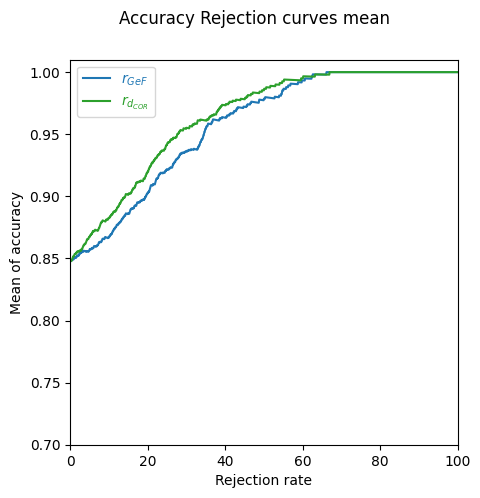

In [48]:
DB = 'Wave'
p1="mean"
combine_plots_acc_rej(rob_measures = dict_wav_b,
                      classification_results = class_wav_b,
                      set_name="", fig_size=(5,5), mean=True, stddev=False, keys=None,
                      show=True, title_extra="", y_min=0.7, y_max=0.35, legend_loc='upper left',
                      colors=Colors, AUC=False)

In [49]:
rob_measures = dict_wav_b
classification_results = class_wav_b
set_name=""
fig_size=(16,10)
mean=True
stddev=False
percentiles=None
keys=None
show=True
title_extra=""
y_min=0.7
legend_loc='upper left'
legend_location='upper left',
colors=Colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
AUC=False

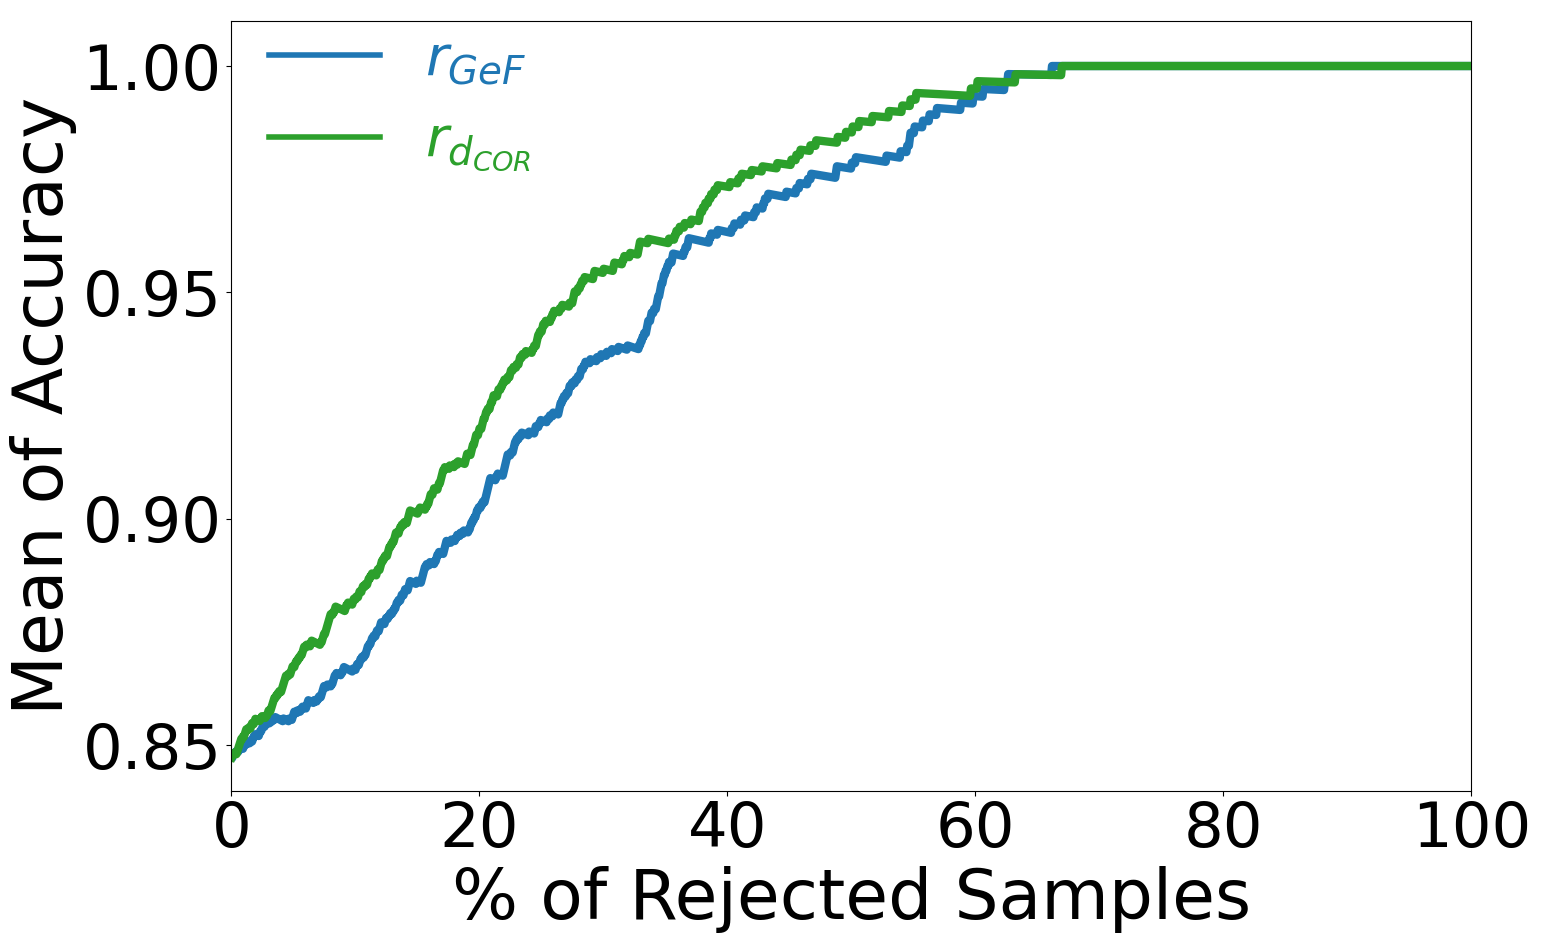

In [51]:
fig, axs = plt.subplots(1, 1, figsize=fig_size)
axs = [axs]

counter = 0
for rob_key in rob_measures:
    if keys is not None:
        if rob_key not in keys:
            continue

    accuracy_rejection_curve(rob_measures[rob_key], classification_results,  ax=axs[0], set_name=None, percentiles=percentiles,
                             color=colors[counter], mean=mean, stddev=stddev, AUC=AUC)
    counter += 1

# titles and legends of the subplots
# axs[0].set_title("All points")
if keys is not None:
    l = keys
else:
    l = list(rob_measures.keys())
    
legend_location = legend_loc
if not mean and stddev:
    if legend_loc == 'empty':
        legend_location = 'lower left'
    plt.ylim(0, y_max)
else:
    plt.ylim(.84, 1.01)

axs[0].legend(l, labelcolor=colors, loc=legend_location, prop={'size': 40}, frameon=False, bbox_to_anchor=(-.01,1.05))
axs[0].xaxis.label.set_size(50)
axs[0].yaxis.label.set_size(50)
axs[0].tick_params(axis='both', labelsize=45)
leg = axs[0].get_legend()
for i in range(len(l)):
    leg.legendHandles[i].set_color(colors[i])



leg = axs[0].get_legend()
for i in range(len(l)):
    leg.legendHandles[i].set_color(colors[i])
    leg.legendHandles[i].set_linewidth(4)
for line in axs[0].lines:
    line.set_linewidth(6)  # Set all lines to width 2.5
    
# plt.tight_layout()
plt.xlim(0, 100)
axs[0].set_xlabel("% of Rejected Samples")  # X-axis label
axs[0].set_ylabel("Mean of Accuracy")  # Y-axis label

plt.show()